## Imports & Functions

In [10]:
import pickle 
import logging
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import plotly.graph_objects as go

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

import tigramite.data_processing as td
import tigramite.plotting as tp
from tigramite.causal_effects import CausalEffects

from typing import Optional

In [11]:
logging.basicConfig(
    level=logging.INFO,              
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    stream=sys.stdout
)
logger = logging.getLogger(__name__)
logging.getLogger("graph_validation_CI").setLevel(logging.CRITICAL)


In [12]:
def load_ts_df(
    file_path: Path, 
) -> pd.DataFrame:
    """Load q/climate ts df from LamaH-CE, and change index to datetime."""

    df = pd.read_csv(filepath_or_buffer=file_path, header=0, sep=";")

    df_date_index = (df
    .assign(date=pd.to_datetime(df.rename(columns={"DD": "day", "MM": "month", "YYYY": "year"})[["year", "month", "day"]]))
    .drop(columns=["DD", "MM", "YYYY"])
    .set_index("date")
    )
    return df_date_index

def calculate_snowmelt(
        climate_ts_df: pd.DataFrame
) -> pd.DataFrame: 
    """Calculate snowmelt as depletion of SWE from t-1 to t in basin."""

    snow_ts = climate_ts_df.swe

    # First day cannot have depletion.
    snow_depletion = [np.nan]
    prev = snow_ts.iloc[0]

    for day in range(1, len(snow_ts)):

        current = snow_ts.iloc[day]

        # Calculate delta swe from t-1 to t, if positive denote, else 0.
        depletion = prev - current

        if depletion > 0: 

            snow_depletion.append(depletion)

        else: 

            snow_depletion.append(0)

        prev = current

    # Sanity check. 
    logger.info(
        "Calculated snowmelt:"
        f"\n min  : {np.nanmin(snow_depletion)}"
        f"\n max  : {np.nanmax(snow_depletion)}"
        f"\n mean : {np.nanmean(snow_depletion)}"
    )

    # Add to df.
    climate_ts_df["snowmelt"] = snow_depletion

    return climate_ts_df

def construct_vars_tg(
        lamah_ce_path: Path, 
        basin_id: int,
        upstream_basin_id: Optional[int] = None
) -> pd.DataFrame: 

    # Load df's. 
    climate_ts_path = lamah_ce_path / f"B_basins_intermediate_all/2_timeseries/daily/ID_{basin_id}.csv"
    q_ts_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{basin_id}.csv"

    climate_ts_df = load_ts_df(climate_ts_path) 
    q_ts_df = load_ts_df(q_ts_path) 
    logger.info(f"Loaded data from:\n{climate_ts_path}\n{q_ts_path}")

    climate_ts_df = calculate_snowmelt(climate_ts_df=climate_ts_df)

    # Select only relvant climate vars.
    climate_vars_df = climate_ts_df.loc[:, ["surf_net_solar_rad_mean", "2m_temp_mean", "prec", "total_et", "volsw_123", "snowmelt"]]

    # Add discharge
    vars_df = pd.concat([climate_vars_df, q_ts_df["qobs"]], axis=1)

    # Add Q_in if available.
    if upstream_basin_id: 

        q_upstream_ts_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{upstream_basin_id}.csv"

        q_upstream_ts_df = load_ts_df(q_upstream_ts_path)

        logger.info(f"Loaded upstream basin data from: {q_upstream_ts_path}")

        vars_df = pd.concat([vars_df, q_upstream_ts_df["qobs"]], axis=1)

        # might need to be adapted for multiple upstream basins. 

    
    # Rename for easier access.
    if not upstream_basin_id:
        vars_df.columns = ["RAD", "TEMP", "P", "ET", "SM", "SNO", "Q"]
    else:
        vars_df.columns = ["RAD", "TEMP", "P", "ET", "SM", "SNO", "Q", "Q_i"]

    # Remove missing.
    vars_df = vars_df.dropna()

    if vars_df.isna().any(axis=None): 
        logger.error("vars_df still conains NA.")
        raise

    # Convert to tigramite form. 
    vars_tg = td.DataFrame(data=vars_df.to_numpy(), var_names=vars_df.columns)

    logger.info(f"Variable names in vars_tg: {vars_tg.var_names}")

    return vars_tg, vars_df

# Plot utils 
def add_rev_contemp_links(
        graph: np.ndarray
) -> np.ndarray: 

    n_vars = graph.shape[0]

    for i in range(n_vars): 

        for j in range(n_vars): 

            # Check if i has contemp link to j [i, j, 0], and if so add reverse. 
         
            if graph[i,j,0] == "-->":

                graph[j,i,0] = "<--"

    return graph

def add_self_causation(
        graph: np.ndarray, 
        var_ids: Optional[list[int]] = None
) -> np.ndarray: 

    if var_ids: 

        for i in var_ids: 

            graph[i, i, 1] = "-->"

        return graph

    # If no subset is provided, add links for all vars. 
    n_vars = graph.shape[0]

    for i in range(n_vars): 

        # Add timelag 1 arrow.
        graph[i, i, 1] = "-->"

    return graph

def construct_node_color_dict(
        colors: list, 
        tau_max: int
) -> dict: 

    node_color_dict = {}

    for i, color in enumerate(colors): 

        for j in range(tau_max + 1): 

            node_color_dict[(i, -j)] = color

    return node_color_dict

def construct_edge_color_matrix(
        graph: np.ndarray
) -> np.ndarray: 

    edge_color_matrix =  graph.copy()

    n_vars = graph.shape[0]
    tau_max = graph.shape[2]

    for p_var in range(n_vars): 

        for c_var in range(n_vars): 

            for t in range(tau_max): 

                if graph[p_var, c_var, t] == "-->": 

                    # Assign id of parent to be used in cmap. 
                    edge_color_matrix[p_var, c_var, t] = p_var

                    # Add color for contemp links. 
                    if t == 0: 

                        edge_color_matrix[c_var, p_var, t] = p_var

                elif graph[p_var, c_var, t] == "<->":

                    edge_color_matrix[p_var, c_var, t] = 7
                    edge_color_matrix[c_var, p_var, t] = 7

    return edge_color_matrix


## Data

In [13]:
#lamah_ce_path = Path("/home/tripleuuu/Nextcloud/coding/causal_inference/snow_causal_inference/data/raw_data/2_LamaH-CE_daily")
lamah_ce_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily")

basin_id = 802

experiment_dir = Path("/home/wuhlmann/CS/causal_inference/snow_causal_inference/experiments") / f"{basin_id}/q_in"
experiment_dir.mkdir(exist_ok=True)

climate_ts_802_path = lamah_ce_path / f"B_basins_intermediate_all/2_timeseries/daily/ID_{basin_id}.csv"
q_ts_802_path = lamah_ce_path / f"D_gauges/2_timeseries/daily/ID_{basin_id}.csv"
catchment_attributes_path = lamah_ce_path / f"B_basins_intermediate_all/1_attributes/Catchment_attributes.csv"

### EDA


In [14]:
climate_ts_802_df = load_ts_df(climate_ts_802_path) 
q_ts_802_df = load_ts_df(q_ts_802_path) 
catchment_attributes_df = pd.read_csv(catchment_attributes_path, header=0, sep=";")
catchment_attributes_df.set_index("ID", inplace=True)

In [15]:
catchment_attributes_df.loc[basin_id, ["area_calc", "elev_mean", "frac_snow", "p_mean"]]

area_calc     140.977
elev_mean    2179.000
frac_snow       0.470
p_mean          3.970
Name: 802, dtype: float64

In [16]:
catchment_attributes_df.loc[:, ["area_calc", "elev_mean", "frac_snow", "p_mean"]].describe()

,area_calc,elev_mean,frac_snow,p_mean
count,859.000000,859.000000,859.000000,859.000000
mean,196.553271,935.362049,0.174831,3.400489
std,262.924854,586.241106,0.122252,0.999311
min,1.316000,143.000000,0.040000,1.730000
25%,58.233500,498.000000,0.080000,2.615000
50%,113.794000,719.000000,0.120000,3.250000
75%,217.764000,1244.000000,0.250000,4.210000
max,2500.384000,3122.000000,0.610000,5.710000


In [17]:
q_ts_802_df.describe()

,qobs,ckhs,qceq,qcol
count,13514.000000,13514.000000,13514.0,13514.000000
mean,5.403674,0.999926,0.0,0.000148
std,4.931249,0.008602,0.0,0.012165
min,0.711000,0.000000,0.0,0.000000
25%,1.705000,1.000000,0.0,0.000000
50%,3.708500,1.000000,0.0,0.000000
75%,7.289250,1.000000,0.0,0.000000
max,40.831000,1.000000,0.0,1.000000


### CEE Prep

In [18]:
vars_tg, vars_df = construct_vars_tg(lamah_ce_path=lamah_ce_path, basin_id=basin_id, upstream_basin_id=801)

2026-09-25 14:43:40 - INFO - Loaded data from:
/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily/ID_802.csv
/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/2_timeseries/daily/ID_802.csv
2026-09-25 14:43:40 - INFO - Calculated snowmelt:
 min  : 0.0
 max  : 32.19999999999999
 mean : 1.9031755950291371
2026-09-25 14:43:40 - INFO - Loaded upstream basin data from: /home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/D_gauges/2_timeseries/daily/ID_801.csv
2026-09-25 14:43:40 - INFO - Variable names in vars_tg: Index(['RAD', 'TEMP', 'P', 'ET', 'SM', 'SNO', 'Q', 'Q_i'], dtype='str')


In [19]:
vars_df

,RAD,TEMP,P,ET,SM,SNO,Q,Q_i
date,,,,,,,,
1981-01-02,27,-12.0,10.66,0.00,0.42,0.0,1.426,0.468
1981-01-03,23,-7.8,11.99,-0.06,0.42,0.0,1.444,0.476
1981-01-04,13,-7.2,23.72,0.08,0.42,0.0,1.273,0.462
1981-01-05,17,-14.3,13.85,0.15,0.42,0.0,1.035,0.468
1981-01-06,12,-14.5,18.40,0.00,0.42,0.0,1.362,0.461
...,...,...,...,...,...,...,...,...
2017-12-27,16,-6.5,19.45,-0.03,0.42,0.0,1.892,0.615
2017-12-28,20,-11.9,7.47,0.15,0.42,0.0,1.866,0.608
2017-12-29,35,-16.9,4.31,0.08,0.42,0.0,1.767,0.596


(<Figure size 2000x1000 with 8 Axes>,
 array([<Axes: ylabel='RAD'>, <Axes: ylabel='TEMP'>, <Axes: ylabel='P'>,
        <Axes: ylabel='ET'>, <Axes: ylabel='SM'>, <Axes: ylabel='SNO'>,
        <Axes: ylabel='Q'>, <Axes: ylabel='Q_i'>], dtype=object))

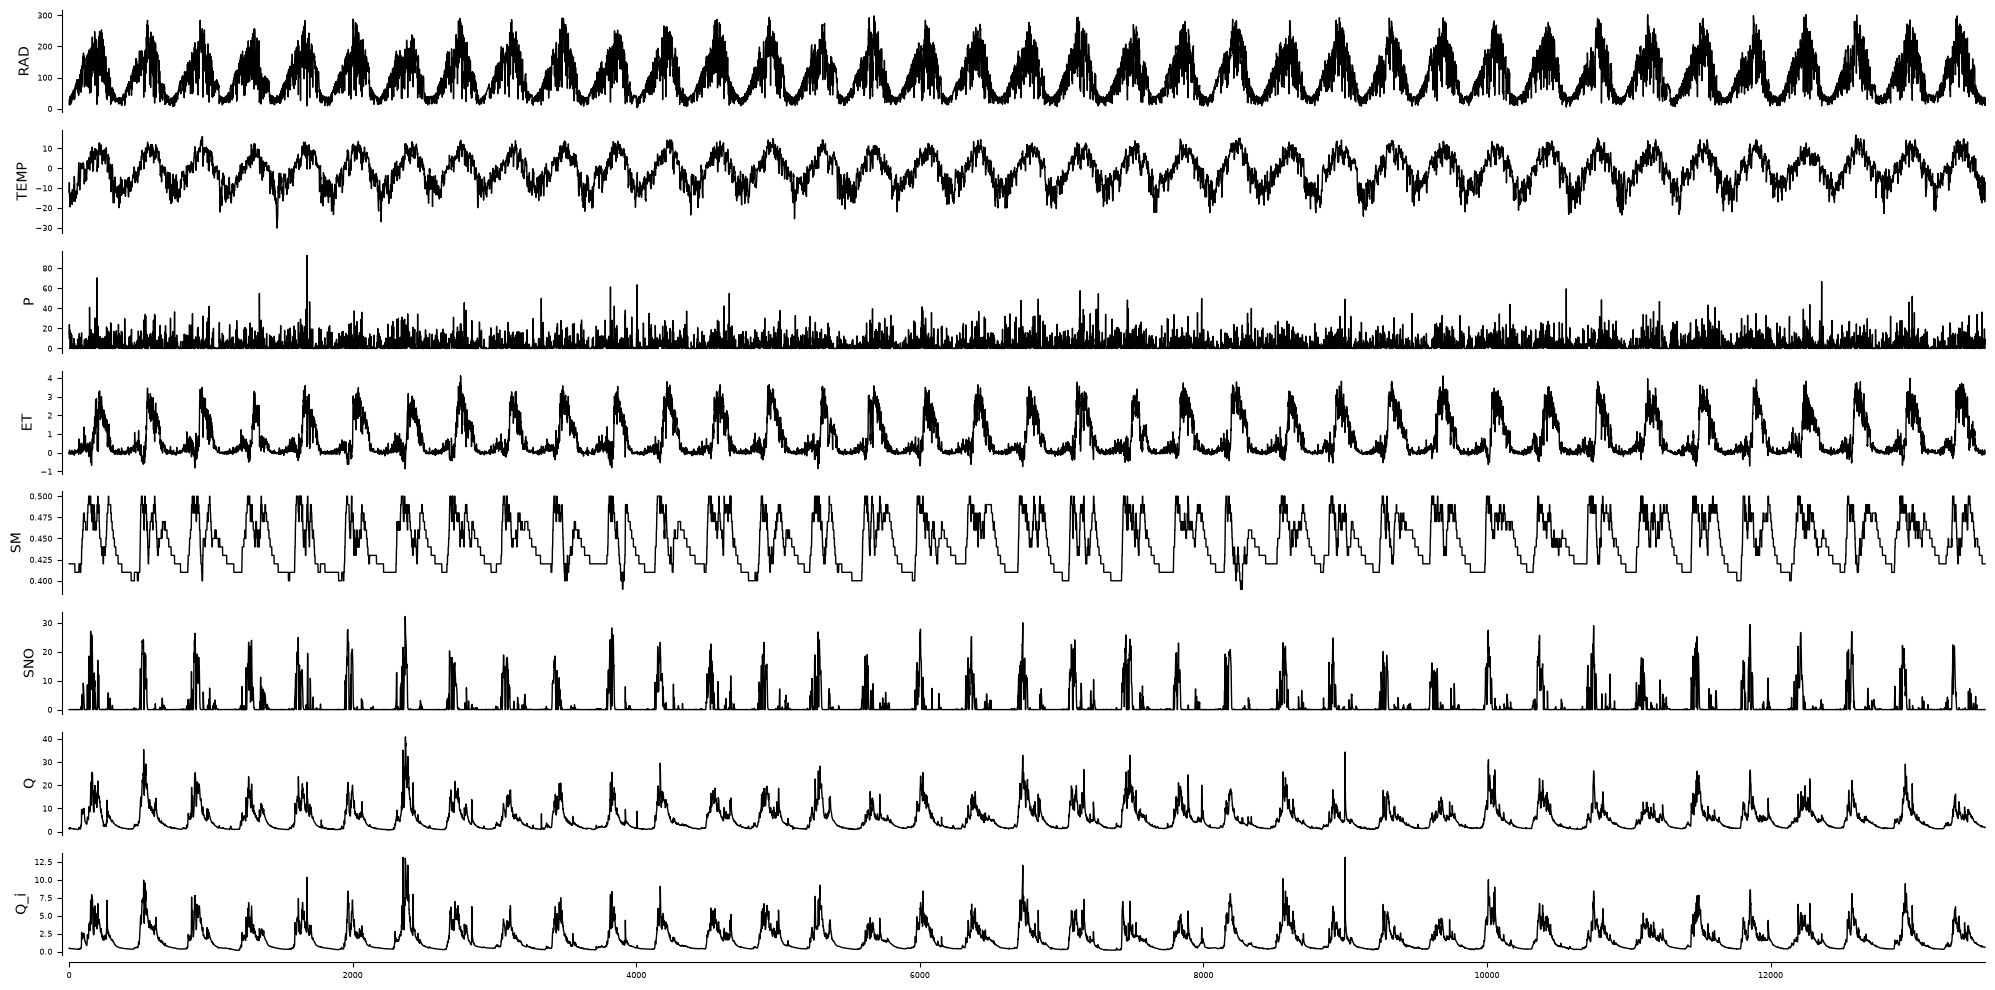

In [20]:
tp.plot_timeseries(dataframe=vars_tg, figsize=(20,10))

Check for seasons with no snowmelt.

In [21]:
fig = go.Figure(data=go.Scatter(
    x=vars_df.index,
    y=vars_df.TEMP,
    mode='lines'
))

fig.add_scatter(x=vars_df.index, y=vars_df.RAD, mode="lines")

fig.update_layout(title="Snowmelt 1981-2017")
fig.show()

In [22]:
var_names_with_id = []

for i, var_name in enumerate(vars_df.columns): 

    var_names_with_id.append(f"{i} {var_name}")

## 1. Graph-Validation 

Check that the distribution is markov to the graph. 

### First draft of graph

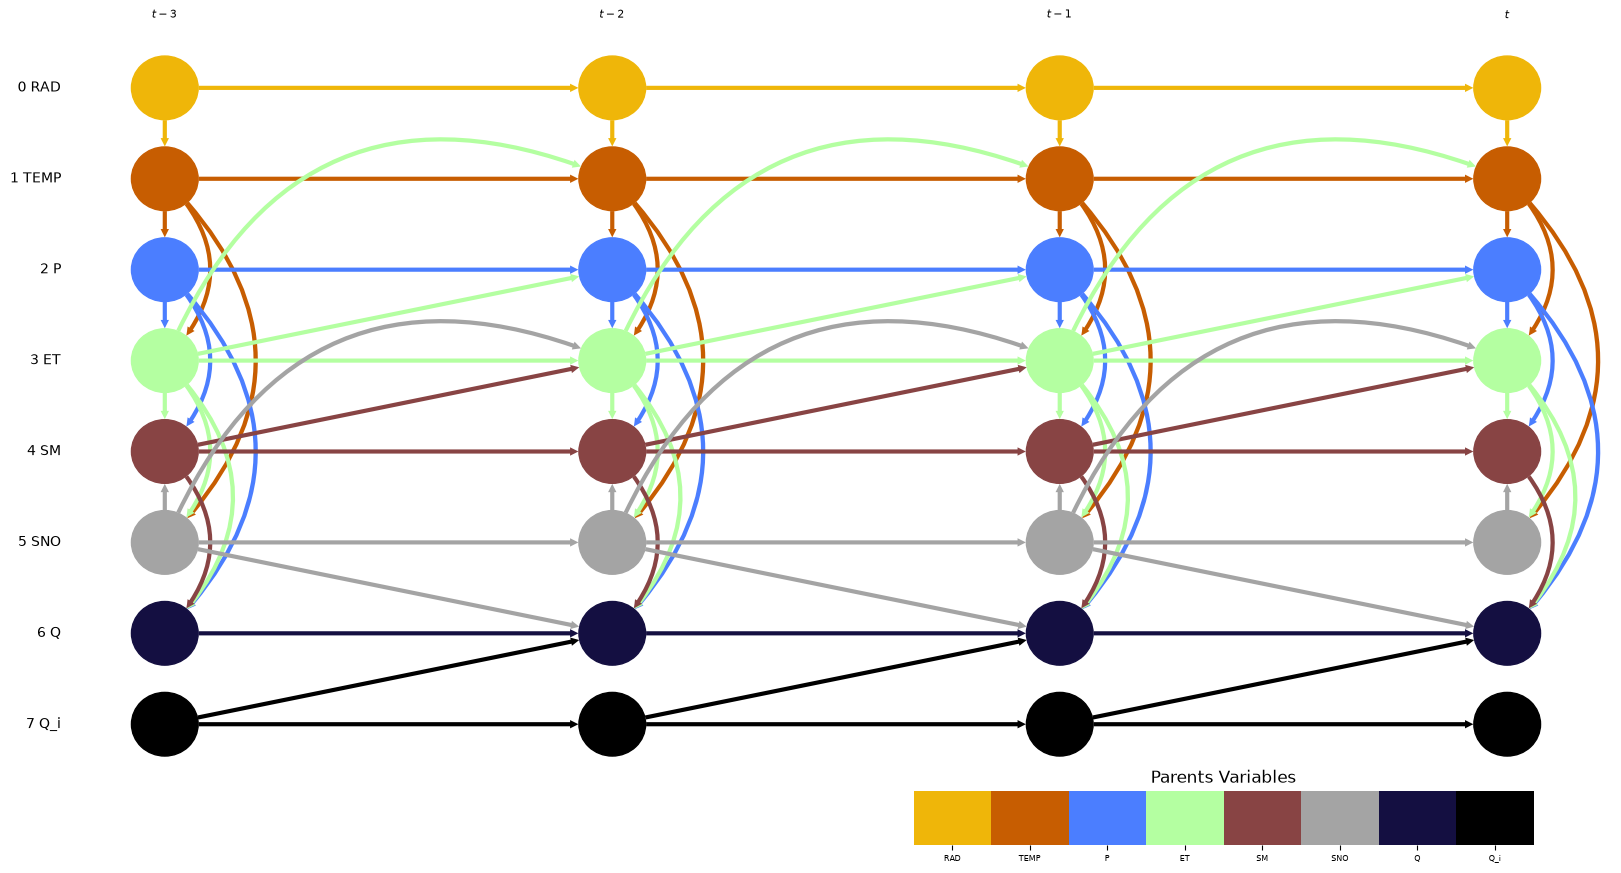

In [23]:
# define tigramite graph and plot it 
draft = 1

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

# Q_in 
graph[7, 6, 1] = "-->" # upstream discharge

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

custom_colors = ["#efb609", "#c75d01", "#4b7eff", "#b4ffa1", "#884444", "#a4a4a4", "#140f41", "#000000"] 
cmap = ListedColormap(custom_colors)


node_color_dict = construct_node_color_dict(colors=custom_colors, tau_max=tau_max)
edge_color_matrix = construct_edge_color_matrix(graph=graph)

fig, ax = plt.subplots(figsize=(20, 10))

tp.plot_time_series_graph(
    graph=graph,
    var_names=var_names_with_id,
    arrow_linewidth=3,
    curved_radius=0.5,
    figsize=(20,10),
    special_nodes=node_color_dict,
    val_matrix=edge_color_matrix,
    cmap_edges=cmap,
    vmin_edges=0,                     
    vmax_edges=8,                     
    edge_ticks=1.0,
    fig_ax=(fig, ax)
)

for cax in ax.child_axes:
    if cax.get_label() == "inset_axes":
        cax.set_xticks(np.arange(len(vars_df.columns)) + 0.5)   # Ticks mittig auf den Farbfeldern
        cax.set_xticklabels(vars_df.columns)
        cax.set_xlabel("") 
        cax.set_title("Parents Variables")

##### Plot Scatters

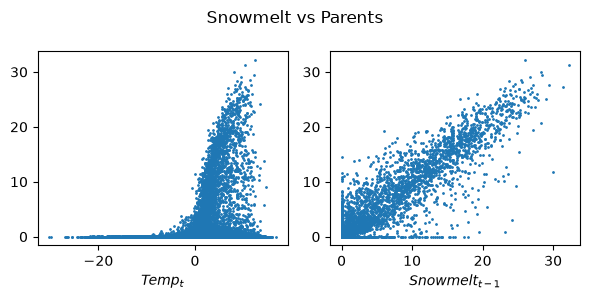

In [24]:
# Plot snow vs parents
fig, axs = plt.subplots(1, 2, figsize=(6,3))

size = 1

axs[0].scatter(x=vars_df.TEMP, y=vars_df.SNO, s=size)
axs[0].set_xlabel("$Temp_t$")
axs[1].scatter(x=vars_df.SNO[:-1], y=vars_df.SNO[1:], s=size)
axs[1].set_xlabel("$Snowmelt_{t-1}$")

fig.suptitle("Snowmelt vs Parents")
#fig.supylabel("$Snowmelt_t$", rotation=0)
plt.tight_layout()

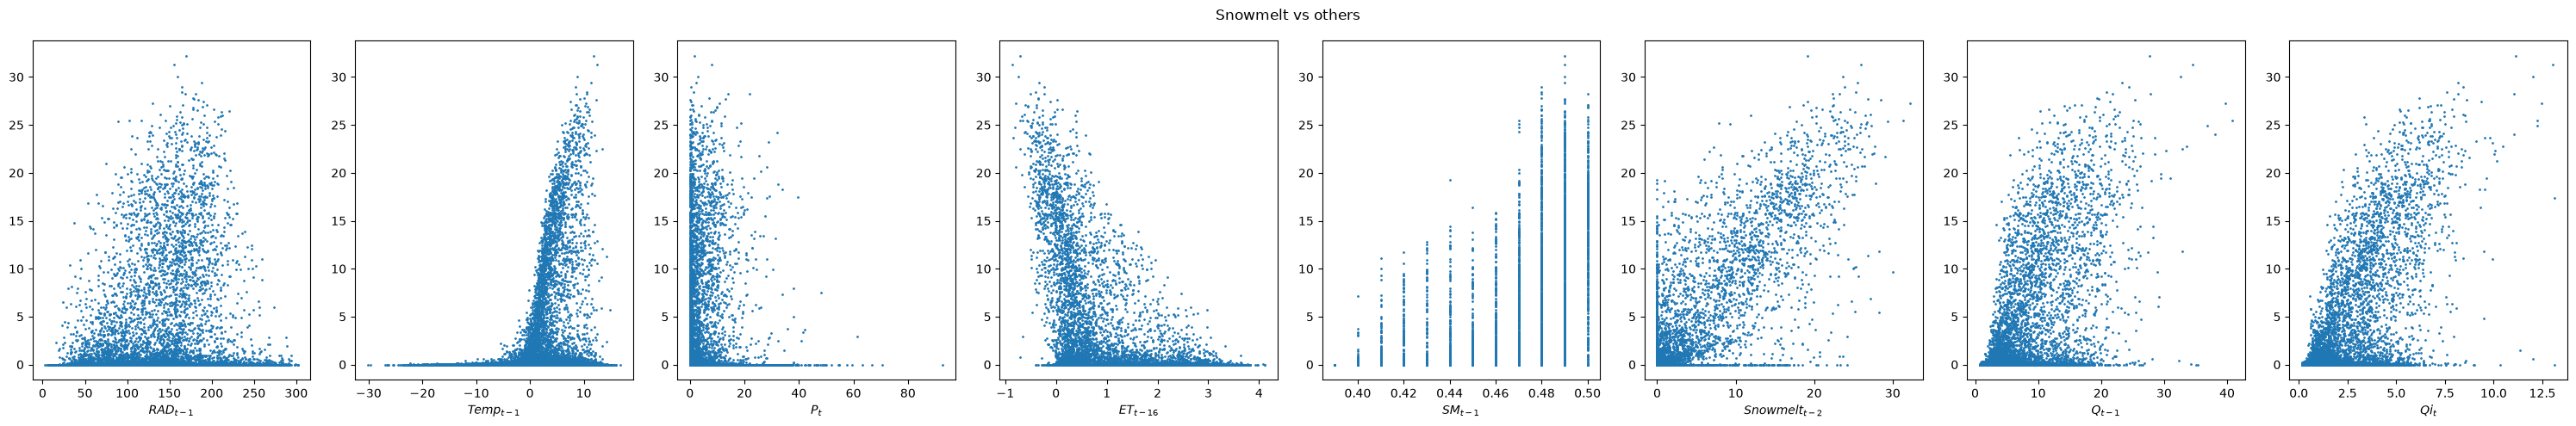

In [25]:
# Plot snow vs others 

fig, axs = plt.subplots(1, 8, figsize=(30,5))

axs[0].scatter(x=vars_df.RAD[:-1], y=vars_df.SNO[1:], s=size)
axs[0].set_xlabel("$RAD_{t-1}$")
axs[1].scatter(x=vars_df.TEMP[:-1], y=vars_df.SNO[1:], s=size)
axs[1].set_xlabel("$Temp_{t-1}$")
axs[2].scatter(x=vars_df.P, y=vars_df.SNO, s=size)
axs[2].set_xlabel("$P_t$")
axs[3].scatter(x=vars_df.ET[:-1], y=vars_df.SNO[1:], s=size)
axs[3].set_xlabel("$ET_{t-16}$")
axs[4].scatter(x=vars_df.SM[:-1], y=vars_df.SNO[1:], s=size)
axs[4].set_xlabel("$SM_{t-1}$")
axs[5].scatter(x=vars_df.SNO[:-2], y=vars_df.SNO[2:], s=size)
axs[5].set_xlabel("$Snowmelt_{t-2}$")
axs[6].scatter(x=vars_df.Q[:-1], y=vars_df.SNO[1:], s=size)
axs[6].set_xlabel("$Q_{t-1}$")
axs[7].scatter(x=vars_df.Q_i, y=vars_df.SNO, s=size)
axs[7].set_xlabel("$Qi_t$")

fig.suptitle("Snowmelt vs others")
#fig.supylabel("$Snowmelt_t$")
plt.tight_layout()

##### Formulate dict with configuration for CI tests. 

In [26]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    "basin_id": basin_id,

    "upstream_basin_id": 801,

    (5,0) : {
        "X_dict": {
            #(0, 0)  : [(0, -1)],
            #(1, -1) : [(0, -1), (1, -2), (3, -2)],
            #(2, 0)  : [(1, 0), (2, -1), (3, -1)],
            #(3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2)],
            #(4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)],
            #(5, -2) : [(1, -2), (3, -2), (5, -3)],
            #(6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)],
            (7, -1)  : [(7, -2)]
        },                   
        "Y_parents": [(1, 0), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [27]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{'CI_results_dict_25-09-2026_12:32:20.pkl': {'use_Pa_X': True,
  'val_d': False,
  'basin_id': 802,
  'upstream_basin_id': 801,
  (5,
   0): {'X_dict': {(0, 0): [(0, -1),
     (np.float64(0.019197902852196247), 0.001996007984031936, True)],
    (1, -1): [(0, -1),
     (1, -2),
     (3, -2),
     (np.float64(0.0036936121819426404), 0.001996007984031936, True)],
    (2, 0): [(1, 0),
     (2, -1),
     (3, -1),
     (np.float64(0.035452442249397365), 0.001996007984031936, True)],
    (3, -1): [(1, -1),
     (2, -1),
     (3, -2),
     (4, -2),
     (5, -2),
     (np.float64(0.003390917161637752), 0.001996007984031936, True)],
    (4, -1): [(2, -1),
     (3, -1),
     (4, -2),
     (5, -1),
     (np.float64(0.0019624517841045908), 0.001996007984031936, True)],
    (5, -2): [(1, -2),
     (3, -2),
     (5, -3),
     (np.float64(-0.003028971285762516), 0.9860279441117764, False)],
    (6, -1): [(2, -1),
     (3, -1),
     (4, -1),
     (5, -2),
     (6, -2),
     (np.float64(0.00151111267627

### Second Draft

(<Figure size 640x480 with 1 Axes>, <Axes: >)

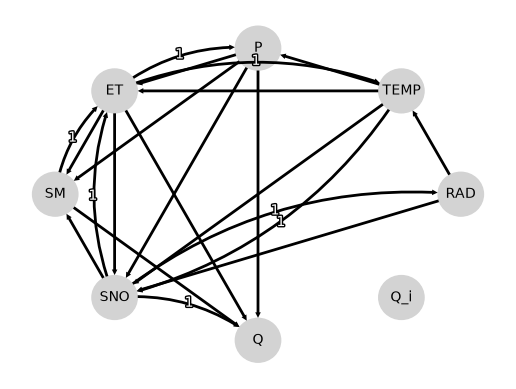

In [28]:
# define tigramite graph and plot it 
draft = 2

N = len(vars_df.columns)
tau_max = 3  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp
graph[0, 5, 0] = "-->" # NEW: RAD drives SNO, as energy flux

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO
graph[1, 5, 1] = "-->" # NEW: also lagged via heat storage in soil

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 5, 0] = "-->" # NEW: ROS 
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 0, 1] = "-->" # NEW: drives incoming RAD via albedo decrease
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=2,
)

(<Figure size 1000x500 with 1 Axes>, <Axes: >)

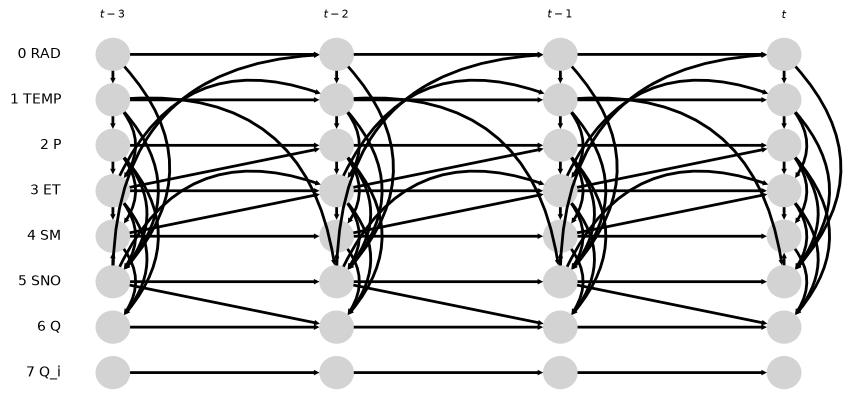

In [29]:
tp.plot_time_series_graph(graph=graph, var_names=var_names_with_id, curved_radius=0.5, arrow_linewidth=2, figsize=(10, 5))

##### Formulate dict with configuration for CI tests. 

In [30]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    (5,0) : {
        "X_dict": {
            (0, -1) : [(0, -2), (5, -2)],
            (1, -2) : [(0, -2), (1, -3), (3, -3)],
            (2, -1) : [(1, -1), (2, -2), (3, -2)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2)],
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)],
            (5, -2) : [(0, -2), (1, -2), (3, -2), (5, -3)],
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)] # unchanged
        },                   
        "Y_parents": [(0, 0), (1, 0), (1, -1), (2, 0), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [31]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{}

### Third Draft

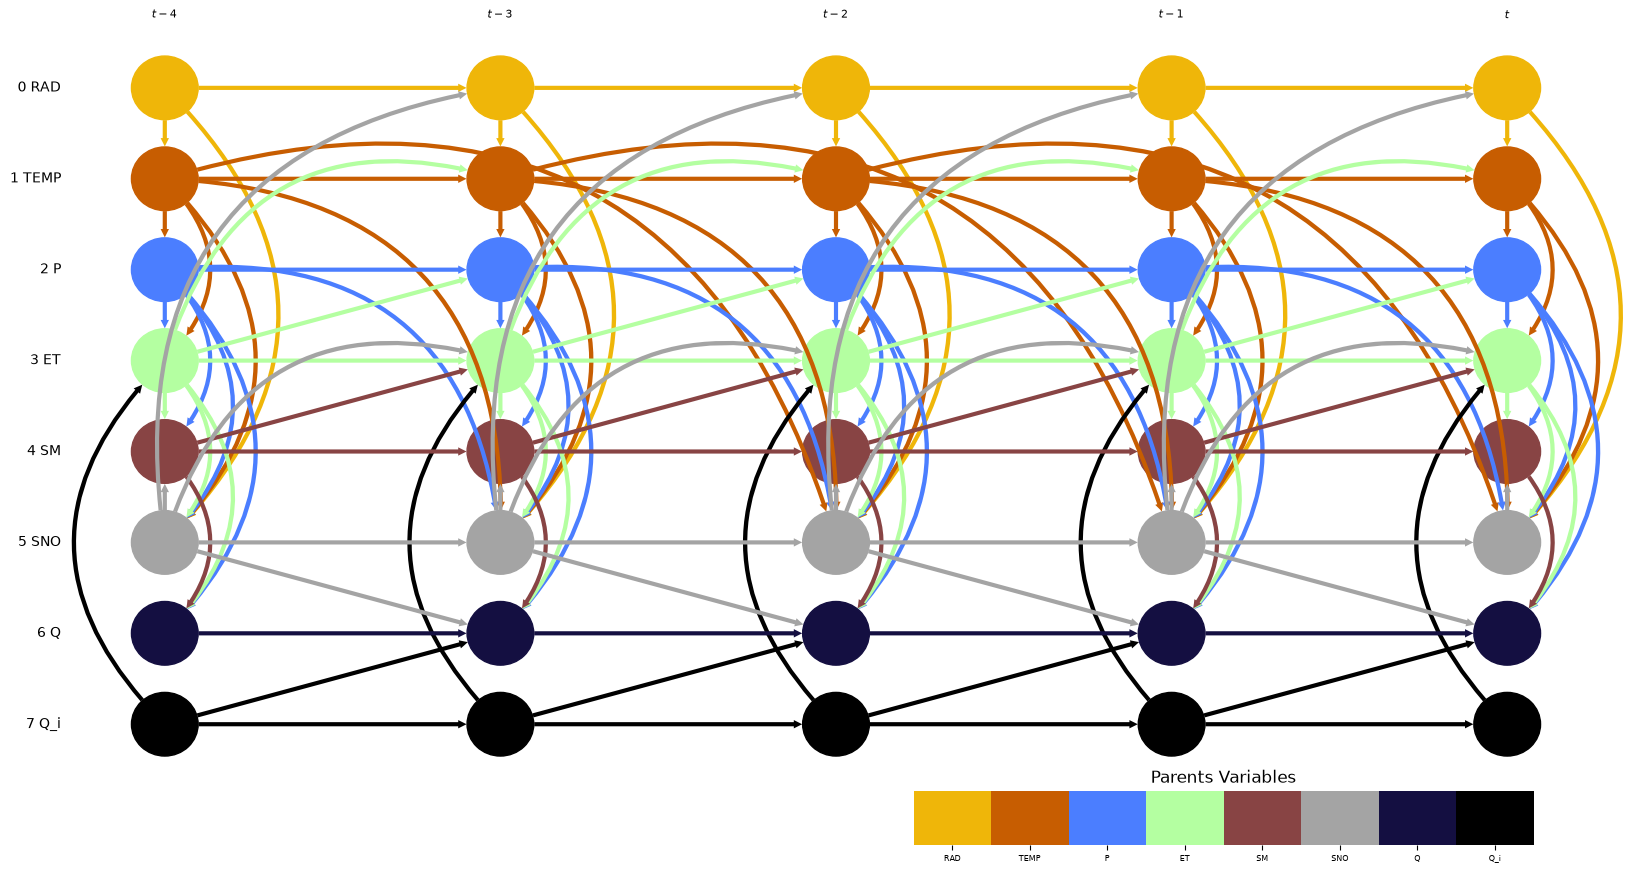

In [32]:
# define tigramite graph and plot it 
draft = 3

N = len(vars_df.columns)
tau_max = 4  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp
graph[0, 5, 0] = "-->" # RAD drives SNO, as energy flux

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO
graph[1, 5, 1] = "-->" # lso lagged via heat storage in soil
graph[1, 5, 2] = "-->" # NEW: also 2 lagged via heat storage in soil

# P 
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 5, 0] = "-->" # ROS 
graph[2, 5, 1] = "-->" # NEW water in snow persists for some time (up to seven days)
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 0, 1] = "-->" # NEW: drives incoming RAD via albedo decrease
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

# Q_in 
graph[7, 3, 0] = "-->" # avail water for ET
graph[7, 6, 1] = "-->" # upstream discharge

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)


node_color_dict = construct_node_color_dict(colors=custom_colors, tau_max=tau_max)

edge_color_matrix = construct_edge_color_matrix(graph=graph)

fig, ax = plt.subplots(figsize=(20, 10))

tp.plot_time_series_graph(
    graph=graph,
    var_names=var_names_with_id,
    arrow_linewidth=3,
    curved_radius=0.5,
    figsize=(20,10),
    special_nodes=node_color_dict,
    val_matrix=edge_color_matrix,
    cmap_edges=cmap,
    vmin_edges=0,                     
    vmax_edges=8,                     
    edge_ticks=1.0,
    fig_ax=(fig, ax)
)

for cax in ax.child_axes:
    if cax.get_label() == "inset_axes":
        cax.set_xticks(np.arange(len(vars_df.columns)) + 0.5)   # Ticks mittig auf den Farbfeldern
        cax.set_xticklabels(vars_df.columns)
        cax.set_xlabel("") 
        cax.set_title("Parents Variables")

##### Formulate dict with configuration for CI tests. 

In [33]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    "upstream_basin_id": 801, 

    (5,0) : {
        "X_dict": {
            (0, -1) : [(0, -2), (5, -2)], # unchanged 
            (1, -3) : [(0, -3), (1, -4), (3, -4)],
            (2, -2) : [(1, -2), (2, -3), (3, -3)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2), (7,0)], 
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)], # unchanged
            (5, -2) : [(0, -2), (1, -2), (3, -2), (5, -3)], # unchanged
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2)], # unchanged,
            (7, 0)  : [(7, -1)]
        },                   
        "Y_parents": [(0, 0), (1, 0), (1, -1), (1, -2), (2, 0), (2, -1), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [34]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{}

### Fourth Draft

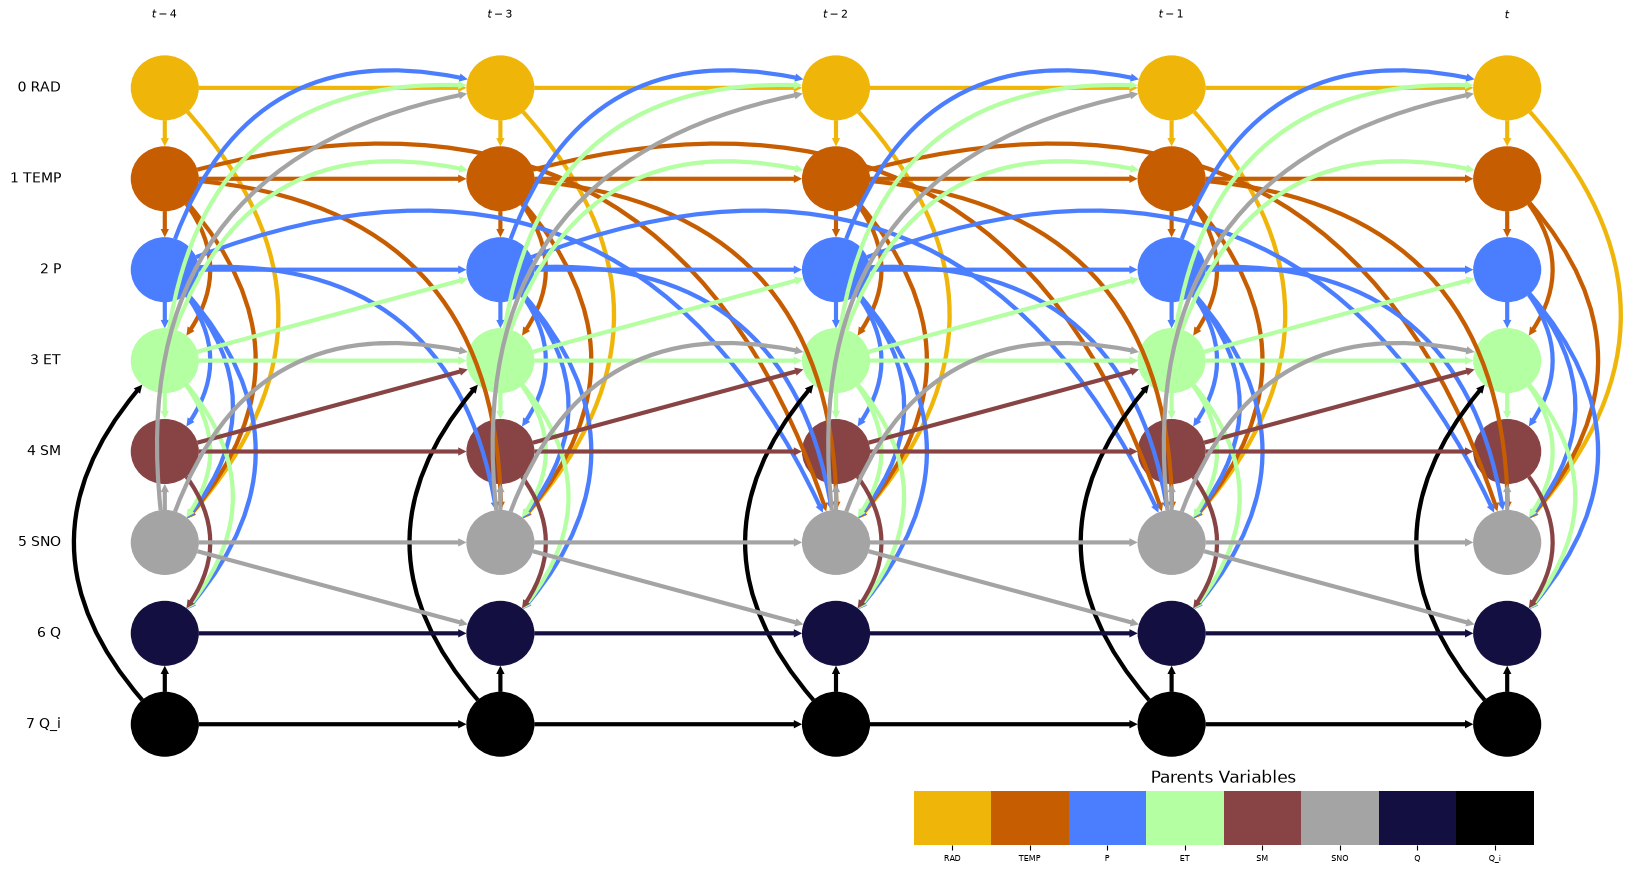

In [35]:
# define tigramite graph and plot it 
draft = 4

N = len(vars_df.columns)
tau_max = 4  

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# RAD 
graph[0, 1, 0] = "-->" # RAD drives Temp
graph[0, 5, 0] = "-->" # RAD drives SNO, as energy flux

# T
graph[1, 2, 0] = "-->" # impacts advection, therefore P
graph[1, 3, 0] = "-->" # controls ET, in terms of energy
graph[1, 5, 0] = "-->" # controls SNO
graph[1, 5, 1] = "-->" # lso lagged via heat storage in soil
graph[1, 5, 2] = "-->" # also 2 lagged via heat storage in soil

# P 
graph[2, 0, 1] = "-->" # clouds
graph[2, 3, 0] = "-->" # limits ET, in terms of availalbe water
graph[2, 4, 0] = "-->" # water source for SM 
graph[2, 5, 0] = "-->" # ROS 
graph[2, 5, 1] = "-->" # water in snow persists for some time (up to seven days)
graph[2, 5, 2] = "-->" # NEW: up to seven days
graph[2, 6, 0] = "-->" # contributes to Q

# ET
graph[3, 0, 1] = "-->" # clouds
graph[3, 1, 1] = "-->" # condensation cools, lagged to avoid cycle
graph[3, 2, 1] = "-->" # condensation drives P 
graph[3, 4, 0] = "-->" # drains SM
graph[3, 5, 0] = "-->" # limits snowmelt by consuming energy to evaporate snow
graph[3, 6, 0] = "-->" # other outflux next to Q 

# SM 
graph[4, 3, 1] = "-->" # after a day of a prec, water from Soil can evaporate
graph[4, 6, 0] = "-->" # water in soil doesnt runoff, if soil saturated more surface discharge

# SNO
graph[5, 0, 1] = "-->" # : drives incoming RAD via albedo decrease
graph[5, 3, 1] = "-->" # supplies available water to evaporate 
graph[5, 4, 0] = "-->" # melt infiltrates
graph[5, 6, 1] = "-->" # melt contributes to Q

# Q_in 
graph[7, 3, 0] = "-->" # avail water for ET
graph[7, 6, 0] = "-->" # avail water for Q

graph = add_self_causation(graph=graph)

graph = add_rev_contemp_links(graph=graph)

node_color_dict = construct_node_color_dict(colors=custom_colors, tau_max=tau_max)

edge_color_matrix = construct_edge_color_matrix(graph=graph)

fig, ax = plt.subplots(figsize=(20, 10))

tp.plot_time_series_graph(
    graph=graph,
    var_names=var_names_with_id,
    arrow_linewidth=3,
    curved_radius=0.5,
    figsize=(20,10),
    special_nodes=node_color_dict,
    val_matrix=edge_color_matrix,
    cmap_edges=cmap,
    vmin_edges=0,                     
    vmax_edges=8,                     
    edge_ticks=1.0,
    fig_ax=(fig, ax)
)

for cax in ax.child_axes:
    if cax.get_label() == "inset_axes":
        cax.set_xticks(np.arange(len(vars_df.columns)) + 0.5)   # Ticks mittig auf den Farbfeldern
        cax.set_xticklabels(vars_df.columns)
        cax.set_xlabel("") 
        cax.set_title("Parents Variables")

##### Formulate dict with configuration for CI tests. 

In [36]:
CI_config_dict = {

    "use_Pa_X": True, 

    "val_d": False,

    "basin_id": basin_id,

    "upstream_basin_id": 801,

    (5,0) : {
        "X_dict": {
            (0, -1) : [(0, -2), (2, -2), (3, -2), (5, -2)], 
            (1, -3) : [(0, -3), (1, -4), (3, -4)],
            (2, -3) : [(1, -3), (2, -4), (3, -4)],
            (3, -1) : [(1, -1), (2, -1), (3, -2), (4, -2), (5, -2), (7,-1)], 
            (4, -1) : [(2, -1), (3, -1), (4, -2), (5, -1)], 
            (5, -2) : [(0, -2), (1, -2), (1, -3), (1, -4), (2, -2), (2, -3), (2, -4), (3, -2), (5, -3)],
            (6, -1) : [(2, -1), (3, -1), (4, -1), (5, -2), (6, -2), (7, -1)],
            (7, -1) : [(7, -2)]
        },                   
        "Y_parents": [(0, 0), (1, 0), (1, -1), (1, -2), (2, 0), (2, -1), (2, -2), (3, 0), (5, -1)]
    },

    "graph": graph
    
}

draft_dir = experiment_dir / f"draft_{draft}"
draft_dir.mkdir(exist_ok=True)

with open(draft_dir / "CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

##### Run tests on node and inspect results.

In [37]:
draft_result_paths = list(draft_dir.glob("*results*"))
draft_results = {}

for path in draft_result_paths: 

    with open(path, "rb") as f: 
        draft_results[path.name] = pickle.load(f)
        
draft_results


{'CI_results_dict_25-09-2026_12:38:41.pkl': {'use_Pa_X': True,
  'val_d': False,
  'basin_id': 802,
  'upstream_basin_id': 801,
  (5,
   0): {'X_dict': {(0, -1): [(0, -2),
     (2, -2),
     (3, -2),
     (5, -2),
     (np.float64(0.002049755296456457), 0.017964071856287425, False)],
    (1, -3): [(0, -3),
     (1, -4),
     (3, -4),
     (np.float64(0.001370845570607404), 0.09181636726546906, False)],
    (2, -3): [(1, -3),
     (2, -4),
     (3, -4),
     (np.float64(0.0012345418125865315), 0.36926147704590817, False)],
    (3, -1): [(1, -1),
     (2, -1),
     (3, -2),
     (4, -2),
     (5, -2),
     (7, 0),
     (np.float64(0.0021826343996123043), 0.017964071856287425, False)],
    (4, -1): [(2, -1),
     (3, -1),
     (4, -2),
     (5, -1),
     (np.float64(0.0016330782455979964), 0.02594810379241517, False)],
    (5, -2): [(0, -2),
     (1, -2),
     (3, -2),
     (5, -3),
     (np.float64(-0.00030830207264997966), 0.8902195608782435, False)],
    (6, -1): [(2, -1),
     (3, -1)

## 2. Causal Effect Estimation

In [38]:
X = [(5, -1)]
Y = [(6, 0)]
causal_effects = CausalEffects(graph=graph, graph_type="stationary_dag", X=X, Y=Y, check_SM_overlap=True, verbosity=1)


##
## Initializing CausalEffects class
##

Input:

graph_type = stationary_dag
X = [(5, -1)]
Y = [(6, 0)]
S = []
M = [(np.int64(4), np.int64(0)), (np.int64(0), np.int64(0)), (np.int64(6), np.int64(-1)), (np.int64(2), np.int64(0)), (np.int64(3), np.int64(0)), (np.int64(5), np.int64(0)), (np.int64(4), np.int64(-1)), (np.int64(1), np.int64(0))]





In [60]:
causal_effects.fit_total_effect(
    dataframe=vars_tg,
    estimator=RandomForestRegressor(oob_score=True),
    adjustment_set=[(0, -1), (1, -1), (1, -2), (1, -3), (2, -1), (2, -2), (2, -3), (3, -1), (5, -2)]
)

/storage/vast-gfz-hpc-01/home/wuhlmann/CS/causal_inference/snow_causal_inference/.pixi/envs/default/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [61]:
from sklearn.metrics import mean_squared_error 

model = causal_effects.model.fit_results["model"]

# Trainingsdaten, die Tigramite tatsächlich verwendet hat
X = causal_effects.model.fit_results["observation_array"].T 
X = np.concat([X[:,0].reshape(-1,1), X[:, 2:]], axis=1)
y = causal_effects.model.fit_results["observation_array"].T[:,1].reshape(-1,1)

y_pred = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, y_pred))
print("RMSE:", rmse)

RMSE: 0.7808486622810306


In [62]:
oob = causal_effects.model.fit_results["model"].oob_score_

In [63]:
intervention_data = 7*np.ones((1, 1)) #do mean + 1 std
y1 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y1 = ",y1)

intervention_data = 0.*np.ones((1, 1))
y2 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y2 = ",y2)
beta = (y1 - y2)
print("Causal effect = %.2f" %(beta[0]))

y1 =  [6.27089387]
y2 =  [5.03911612]
Causal effect = 1.23


In [64]:
vars_df.SNO.describe()

count    13513.000000
mean         1.895453
std          4.760188
min          0.000000
25%          0.000000
50%          0.000000
75%          0.330000
max         32.200000
Name: SNO, dtype: float64

Text(0.5, 1.0, 'Causal Effect')

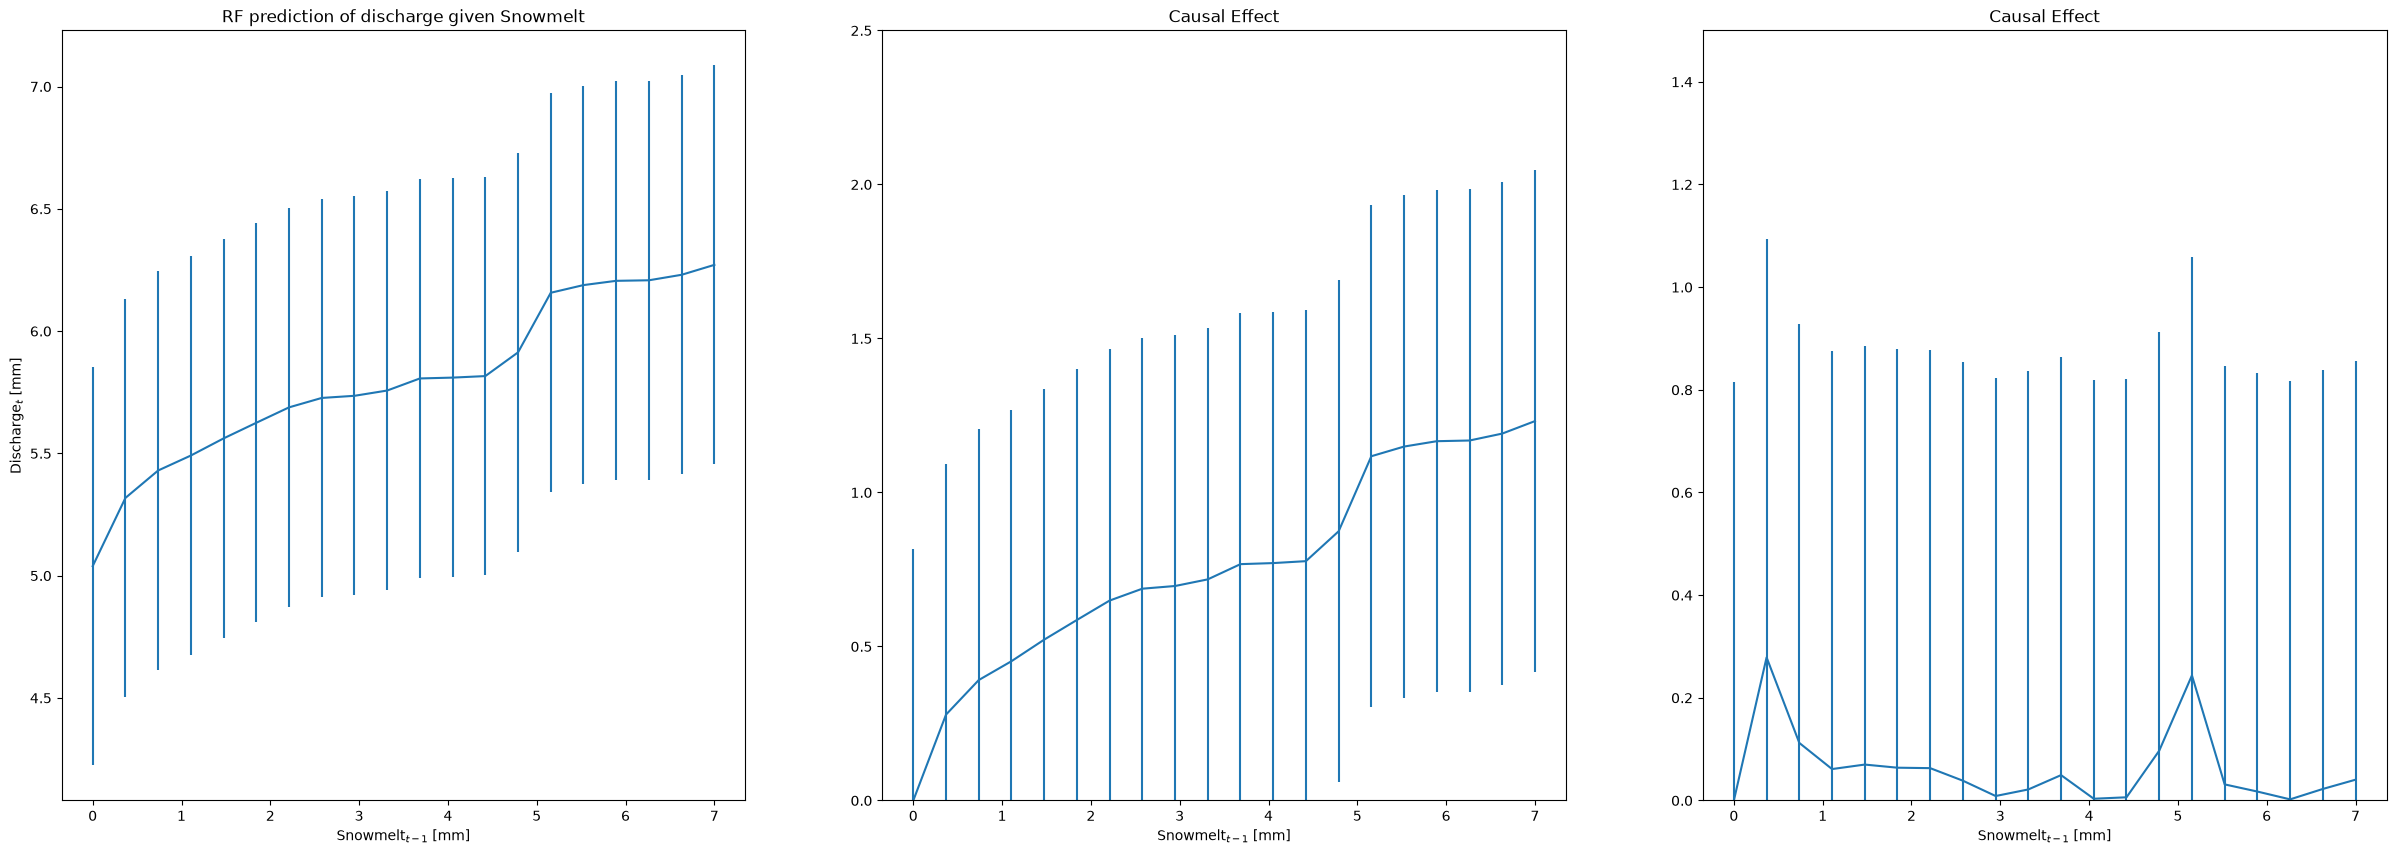

In [65]:
intervention_data = np.linspace(0, 7, 20).reshape(20, 1)
estimated_causal_effects = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )

zero_subtracted_effects = estimated_causal_effects - estimated_causal_effects[0]
right_shifted_effects = np.roll(estimated_causal_effects, 1)
right_shifted_effects[0] = estimated_causal_effects[0]
step_wise_effects = estimated_causal_effects - right_shifted_effects

fig, ax = plt.subplots(1, 3, figsize=(30, 10))

# discharge/snow plot

ax[0].errorbar(intervention_data[:,0], estimated_causal_effects, yerr=oob)
ax[0].set_xlabel("Snowmelt$_{t-1}$ [mm]")
ax[0].set_ylabel("Discharge$_t$ [mm]")
ax[0].set_title("RF prediction of discharge given Snowmelt")

ax[1].errorbar(intervention_data[:,0], zero_subtracted_effects, yerr=oob)
ax[1].set_ylim(0,2.5)
ax[1].set_xlabel("Snowmelt$_{t-1}$ [mm]")
ax[1].set_title("Causal Effect")

ax[2].errorbar(intervention_data[:,0], step_wise_effects, yerr=oob)
ax[2].set_ylim(0,1.5)
ax[2].set_xlabel("Snowmelt$_{t-1}$ [mm]")
ax[2].set_title("Causal Effect")